In [25]:
#Getting the gemeini generative model
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AIMessage , HumanMessage, SystemMessage
from langgraph.graph import MessagesState , START ,END , StateGraph
from IPython.display import display , Image
from pprint import pprint 
from dotenv import load_dotenv
load_dotenv()


True

Inizialize  a Gemini llm model 

In [3]:

llm = ChatGoogleGenerativeAI(
    model = 'gemini-3-flash-preview'
)

A Test of message list 

In [5]:
message = [AIMessage(content="Hi how can i help uh" , name='Model')]
message.extend([HumanMessage(content="Help to fiugure out my life " , name="Puvith") ])
message.extend([AIMessage(content="Life is an wornderfull thing" , name="Model")])
message.extend([HumanMessage(content="How can i underStand the life " , name="Model")])
for i in message:
    i.pretty_print()

================================== Ai Message ==================================
Name: Model

Hi how can i help uh
================================ Human Message =================================
Name: Puvith

Help to fiugure out my life 
================================== Ai Message ==================================
Name: Model

Life is an wornderfull thing
================================ Human Message =================================
Name: Model

How can i underStand the life 


Give the Message to the LLM model 
    

In [6]:
result = llm.invoke(message)
type(result)

langchain_core.messages.ai.AIMessage

Print out the result 

In [7]:
result

AIMessage(content=[{'type': 'text', 'text': 'Understanding life is a journey that people have been on for thousands of years. There is no single "correct" answer, because life means something different to everyone. However, to start understanding it for yourself, it helps to look at it through a few different lenses:\n\n### 1. Life is a Process, Not a Puzzle\nMany people try to "solve" life as if there is a winning move or a final destination where everything becomes clear. Instead, think of life like **music or dancing**. The point of a song isn\'t to get to the last note; the point is to enjoy the music while it’s playing. Understanding life means learning to be present in the "now" rather than always waiting for the future.\n\n### 2. Meaning is "Made," Not "Found"\nWe often wait for a "sign" or a "calling" to tell us why we are here. But for most people, meaning is something you create. You find meaning in:\n*   **What you love:** Hobbies, passions, and creativity.\n*   **Who you lo

In [8]:
result.content

[{'type': 'text',
  'text': 'Understanding life is a journey that people have been on for thousands of years. There is no single "correct" answer, because life means something different to everyone. However, to start understanding it for yourself, it helps to look at it through a few different lenses:\n\n### 1. Life is a Process, Not a Puzzle\nMany people try to "solve" life as if there is a winning move or a final destination where everything becomes clear. Instead, think of life like **music or dancing**. The point of a song isn\'t to get to the last note; the point is to enjoy the music while it’s playing. Understanding life means learning to be present in the "now" rather than always waiting for the future.\n\n### 2. Meaning is "Made," Not "Found"\nWe often wait for a "sign" or a "calling" to tell us why we are here. But for most people, meaning is something you create. You find meaning in:\n*   **What you love:** Hobbies, passions, and creativity.\n*   **Who you love:** Family, fr

In [10]:
result.usage_metadata

{'input_tokens': 34,
 'output_tokens': 1010,
 'total_tokens': 1044,
 'input_token_details': {'cache_read': 0},
 'output_token_details': {'reasoning': 368}}

Tool :  Connenting the external tools 

Createing a quote giving tool 

In [12]:
# The tool which give the quotes based on topic 

def give_quote(topic : str):
    """Function used to give a quote based on the topic given 
    
    Keyword arguments:
    topic -- str : topic of which the quote must be given 
    Return: the quote based ojn the topic 
    """
    return "Be happy always a day without laugter is the day wasted "

In [13]:
llm_with_tools = llm.bind_tools([give_quote])

In [15]:
tool_result = llm_with_tools.invoke([HumanMessage(content="Give me todays best quote of a love life" , name="Puvith")])


In [16]:
tool_result

AIMessage(content=[], additional_kwargs={'function_call': {'name': 'give_quote', 'arguments': '{"topic": "love life"}'}, '__gemini_function_call_thought_signatures__': {'8949dc5c-425e-4ad0-be50-069a70439d62': 'Ep0BCpoBAQw51sf55qrsiUgpTIv5me5k4XhSlTzbTObUcL25+3olT/dVXtUWuaYRU9/YFdptDoVGDUU0hmSaPx+aaF5v6Am+iw/5m9+xYheQBp7mxxOglamfFhovzgtqMv+ZMfOQcyZVKu70n7GDN4rL6+AsAKSrqJpLb1HAGUpFL/P6gR/5iVQUnIuKMD/3VKRb8PiOr2vVR/bzATSzDg=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019de227-15f7-7103-9087-9e6e6cb5733b-0', tool_calls=[{'name': 'give_quote', 'args': {'topic': 'love life'}, 'id': '8949dc5c-425e-4ad0-be50-069a70439d62', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 86, 'output_tokens': 45, 'total_tokens': 131, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 28}})

In [20]:
tool_result.additional_kwargs['function_call']

{'name': 'give_quote', 'arguments': '{"topic": "love life"}'}

Create a Message state 


In [22]:
class State(MessagesState):
    #Build in state 
    #Message State 
    # message : Annotated[list(messages) , add_message]
    # Here add_message will Append the message 
    pass

In [23]:
def tool_calling_llm(state : MessagesState):
    return {
        'messages' : llm_with_tools.invoke(state['messages'])
    }


Build a langgraph Agent 



In [26]:
agent = StateGraph(State)
# Create node 
agent.add_node("tool_calling_llm" , tool_calling_llm)
# Create Edge 

agent.add_edge(START , "tool_calling_llm")
agent.add_edge("tool_calling_llm" , END)



In [28]:
garph = agent.compile()

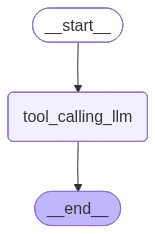

In [29]:
display(Image(garph.get_graph().draw_mermaid_png()))

In [30]:
messages = garph.invoke({
    "messages" : HumanMessage("Hi how are you ")
})

In [31]:
message

[AIMessage(content='Hi how can i help uh', additional_kwargs={}, response_metadata={}, name='Model', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Help to fiugure out my life ', additional_kwargs={}, response_metadata={}, name='Puvith'),
 AIMessage(content='Life is an wornderfull thing', additional_kwargs={}, response_metadata={}, name='Model', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='How can i underStand the life ', additional_kwargs={}, response_metadata={}, name='Model')]

In [32]:
messages = garph.invoke({
    "messages" : HumanMessage("Give me the best quote which says about the morning charm")
})


In [34]:
messages

{'messages': [HumanMessage(content='Give me the best quote which says about the morning charm', additional_kwargs={}, response_metadata={}, id='c32b6cc0-9703-4387-b6db-ae96c00c3b94'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'give_quote', 'arguments': '{"topic": "morning charm"}'}, '__gemini_function_call_thought_signatures__': {'1df8b8db-9835-4f80-b3a5-d1c396fb0dfb': 'EuoBCucBAQw51scrURae2npmckoJH7ky8BtB09tpIJYtExUQYnVdoRivaoXY5xDcEDELqCVjA7ETpUvM7uiwwviaBIdp2bmWK65IY2It0gD62H8UnVa0P4+q0fSaPyHgsY0JmxB9M0wwVBsMFrVvQhGLQE4V+DnlhksEL4sSjOjW+Z7JIzEwDS298NbWBqLiU32XJKfFOU7gKkjnhQwq1znwX1e/mlhkcqk6bQSk+Cdw7lofOfb6ilDXvgXiZoFEzGJch7tXGdj4Rotq/8Ld//cA6PbbBHR4Giw7zemqJ3NQy7oBRjUaOXmw29oZ'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019de2c7-2ef8-7ba3-9ddf-5c83ffb91fc8-0', tool_calls=[{'name': 'give_quote', 'args': {'topic': 'morning charm'}, 'id': '1df8b8d